<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/EF3_to_EF5_Tornado_Activity_Across_the_US_(2013_2026)_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

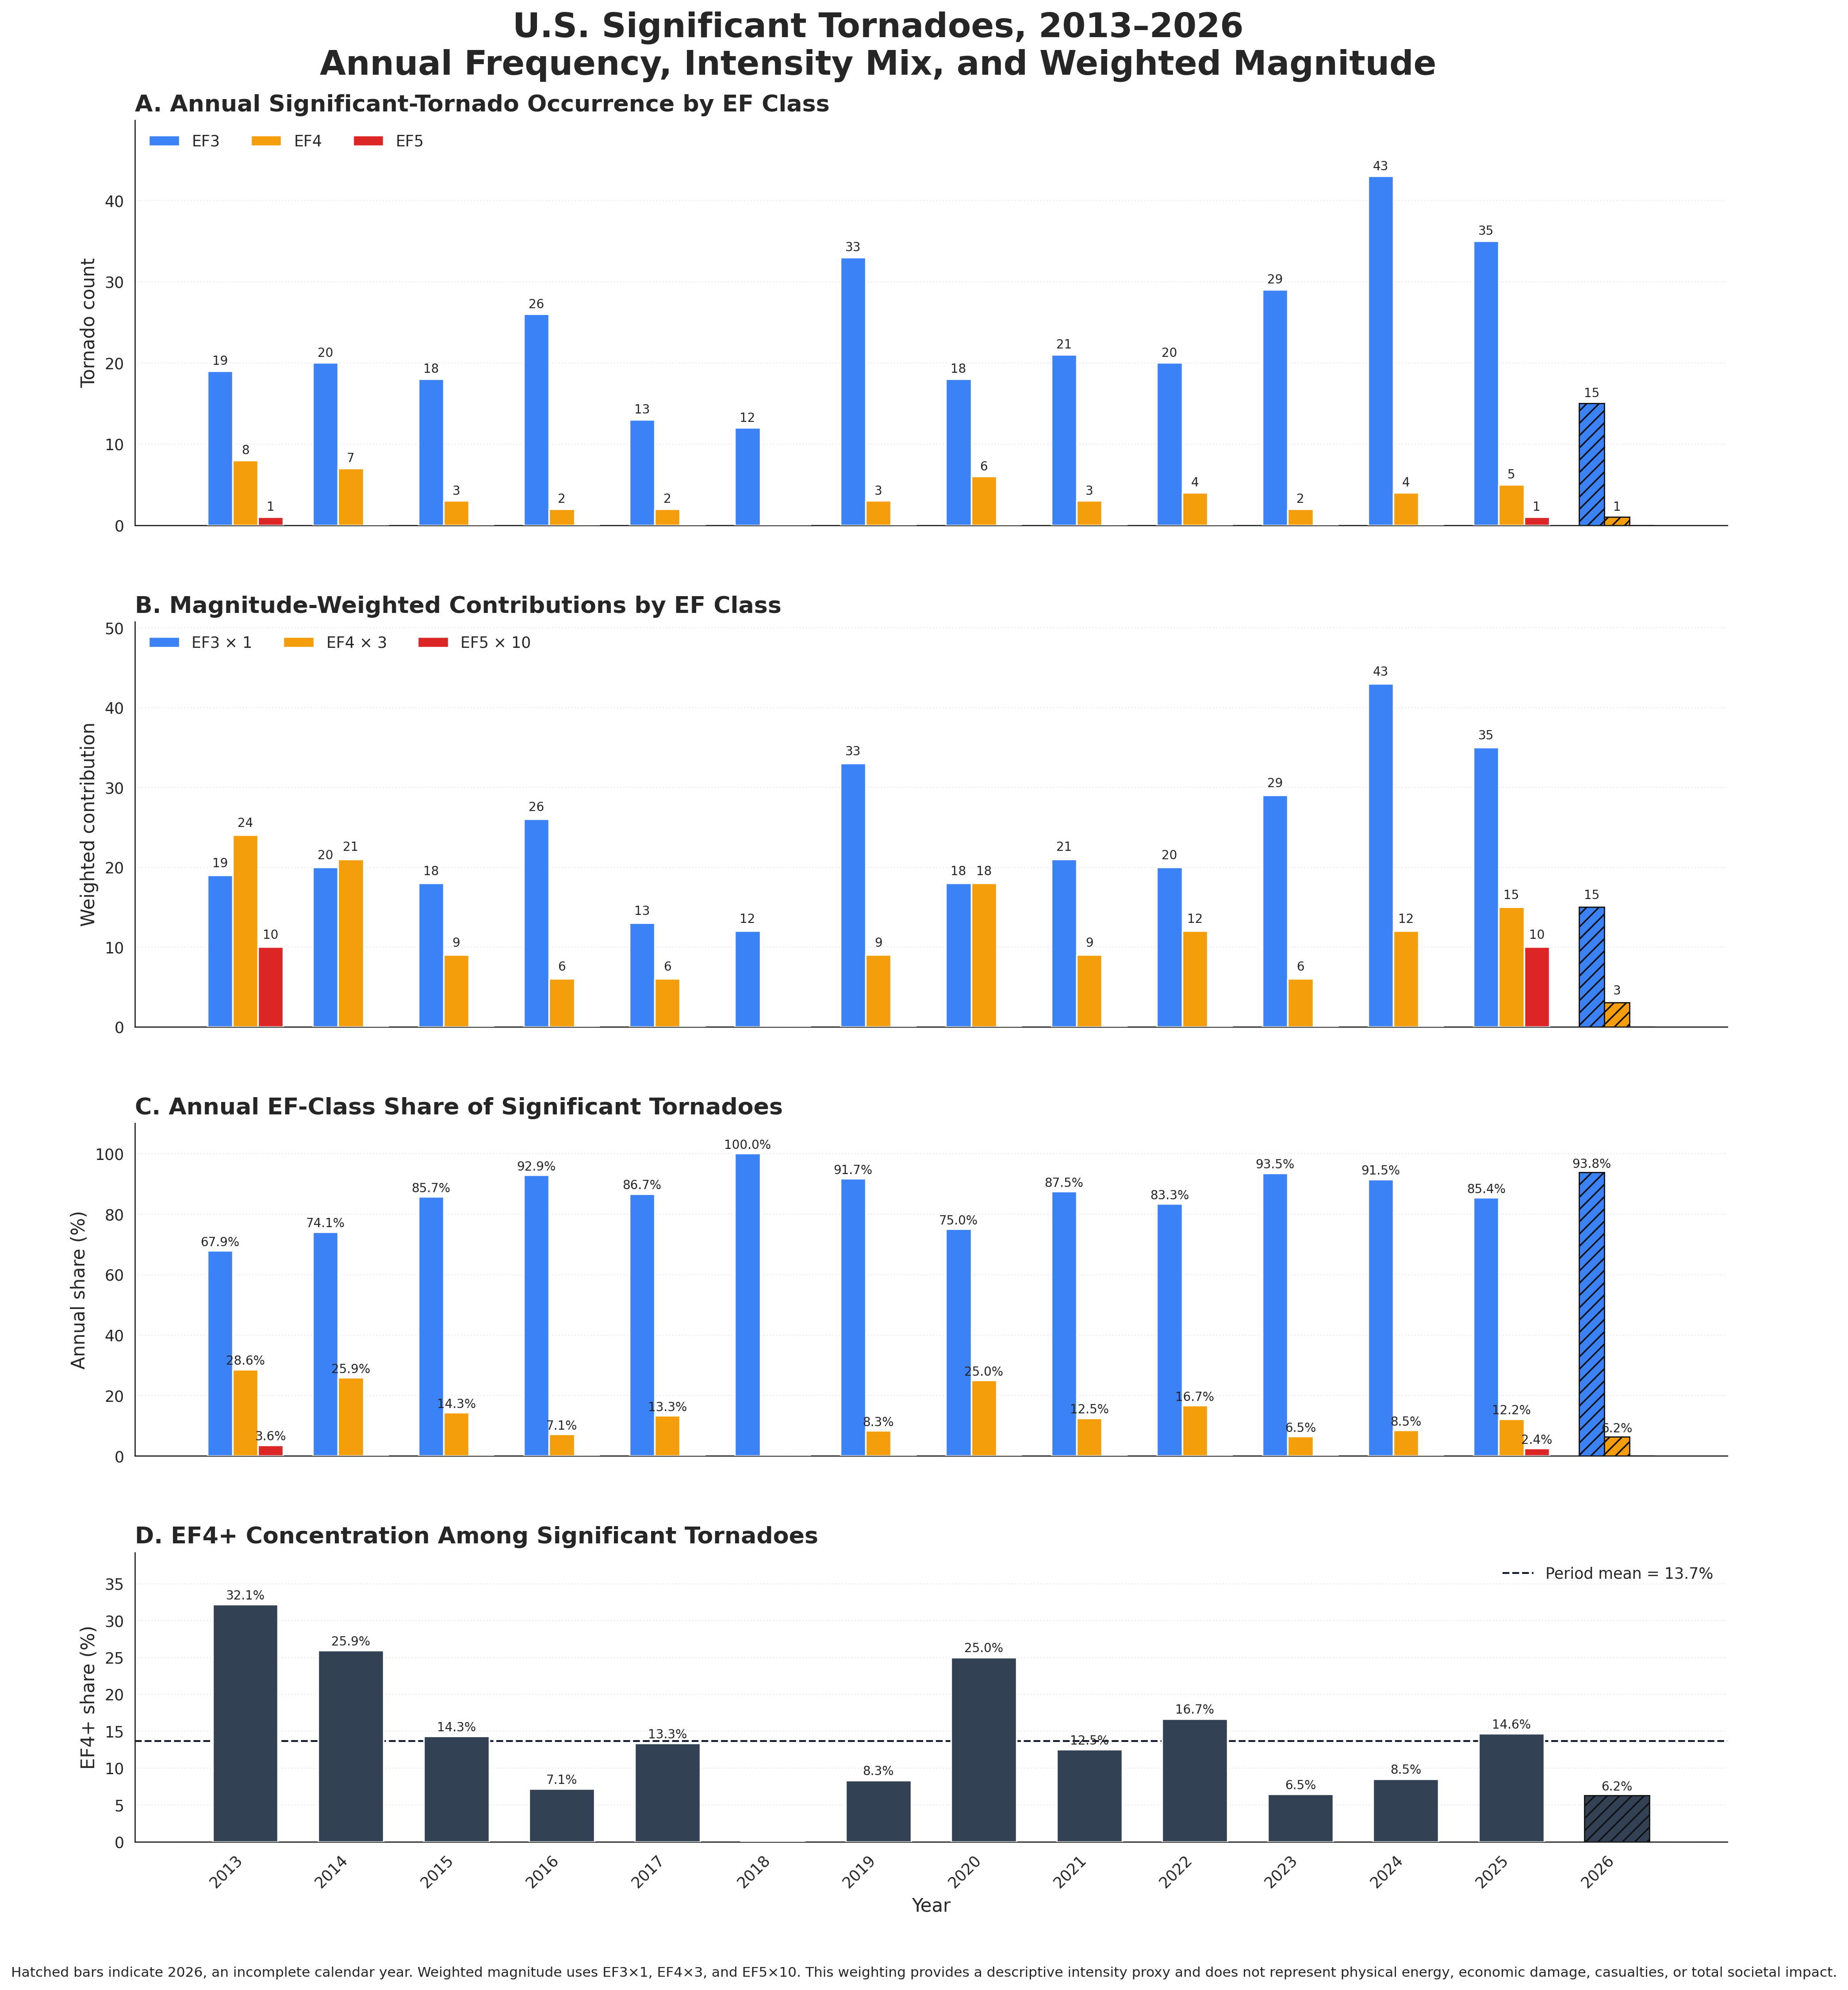

In [8]:
"""
Advanced analysis of U.S. significant tornadoes from 2013 through 2026.

Visualizes annual EF3, EF4, and EF5 occurrence, magnitude-weighted activity,
intensity composition, and the concentration of EF4+ tornadoes using
information-dense grouped bar charts. The weighted intensity score is a
transparent count-derived proxy and should not be interpreted as societal
impact.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------------------------------

CONFIG = {
    "dpi": 250,
    "figsize": (16, 18),
    "bar_width": 0.24,
    "partial_year": 2026,
    "weights": {
        "EF3": 1.0,
        "EF4": 3.0,
        "EF5": 10.0,
    },
    "colors": {
        "EF3": "#3B82F6",
        "EF4": "#F59E0B",
        "EF5": "#DC2626",
        "EF4_Plus": "#334155",
        "reference": "#111827",
    },
    "labels": {
        "main_title": (
            "U.S. Significant Tornadoes, 2013–2026\n"
            "Annual Frequency, Intensity Mix, and Weighted Magnitude"
        ),
        "count_title": (
            "A. Annual Significant-Tornado Occurrence by EF Class"
        ),
        "weighted_title": (
            "B. Magnitude-Weighted Contributions by EF Class"
        ),
        "composition_title": (
            "C. Annual EF-Class Share of Significant Tornadoes"
        ),
        "extreme_title": (
            "D. EF4+ Concentration Among Significant Tornadoes"
        ),
    },
}


plt.rcParams.update(
    {
        "figure.dpi": CONFIG["dpi"],
        "savefig.dpi": CONFIG["dpi"],
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)


# ---------------------------------------------------------------------------
# DATA
# ---------------------------------------------------------------------------

def get_tornado_data():
    """Return annual significant-tornado counts and derived metrics."""
    data = {
        "Year": np.arange(2013, 2027),
        "EF3": [
            19, 20, 18, 26, 13, 12, 33,
            18, 21, 20, 29, 43, 35, 15,
        ],
        "EF4": [
            8, 7, 3, 2, 2, 0, 3,
            6, 3, 4, 2, 4, 5, 1,
        ],
        "EF5": [
            1, 0, 0, 0, 0, 0, 0,
            0, 0, 0, 0, 0, 1, 0,
        ],
    }

    df = pd.DataFrame(data)

    ef_columns = ["EF3", "EF4", "EF5"]

    df["Total"] = df[ef_columns].sum(axis=1)

    for ef_class in ef_columns:
        weight = CONFIG["weights"][ef_class]
        df[f"{ef_class}_Weighted"] = (
            df[ef_class] * weight
        )

    weighted_columns = [
        "EF3_Weighted",
        "EF4_Weighted",
        "EF5_Weighted",
    ]

    df["Weighted_Intensity"] = (
        df[weighted_columns].sum(axis=1)
    )

    df["EF4_Plus"] = (
        df["EF4"] + df["EF5"]
    )

    df["EF4_Plus_Share"] = np.divide(
        100.0 * df["EF4_Plus"],
        df["Total"],
        out=np.zeros(len(df), dtype=float),
        where=df["Total"].to_numpy() > 0,
    )

    for ef_class in ef_columns:
        df[f"{ef_class}_Share"] = np.divide(
            100.0 * df[ef_class],
            df["Total"],
            out=np.zeros(len(df), dtype=float),
            where=df["Total"].to_numpy() > 0,
        )

    return df


# ---------------------------------------------------------------------------
# PLOTTING HELPERS
# ---------------------------------------------------------------------------

def format_axis(axis):
    """Apply consistent scientific-figure formatting."""
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.grid(
        axis="y",
        linestyle=":",
        linewidth=0.8,
        alpha=0.35,
        zorder=0,
    )

    axis.set_axisbelow(True)


def label_bars(
    axis,
    bars,
    values,
    vertical_offset=0.4,
    decimal_places=0,
    suffix="",
    minimum_label_value=0.0,
):
    """Annotate nonzero bar values."""
    for bar, value in zip(bars, values):
        if value <= minimum_label_value:
            continue

        if decimal_places == 0:
            label = f"{value:.0f}{suffix}"
        else:
            label = (
                f"{value:.{decimal_places}f}"
                f"{suffix}"
            )

        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + vertical_offset,
            label,
            ha="center",
            va="bottom",
            fontsize=8,
        )


def hatch_partial_year(
    bar_groups,
    years,
):
    """Hatch bars associated with the incomplete calendar year."""
    partial_year = CONFIG["partial_year"]

    if partial_year not in years:
        return

    partial_index = int(
        np.flatnonzero(
            years == partial_year
        )[0]
    )

    for bars in bar_groups:
        if partial_index >= len(bars):
            continue

        patch = bars[partial_index]

        patch.set_hatch("///")
        patch.set_edgecolor("#111111")
        patch.set_linewidth(0.8)


# ---------------------------------------------------------------------------
# DASHBOARD
# ---------------------------------------------------------------------------

def create_tornado_dashboard(df):
    """Create a four-panel grouped-bar tornado dashboard."""
    years = df["Year"].to_numpy()
    x = np.arange(len(years))

    width = CONFIG["bar_width"]
    colors = CONFIG["colors"]

    ef_classes = [
        "EF3",
        "EF4",
        "EF5",
    ]

    offsets = {
        "EF3": -width,
        "EF4": 0.0,
        "EF5": width,
    }

    fig, axes = plt.subplots(
        4,
        1,
        figsize=CONFIG["figsize"],
        sharex=True,
        gridspec_kw={
            "height_ratios": [
                1.4,
                1.4,
                1.15,
                1.0,
            ],
            "hspace": 0.27,
        },
    )

    (
        ax_count,
        ax_weighted,
        ax_composition,
        ax_extreme,
    ) = axes

    fig.suptitle(
        CONFIG["labels"]["main_title"],
        fontsize=22,
        fontweight="bold",
        y=0.995,
    )

    # -----------------------------------------------------------------------
    # A. ABSOLUTE ANNUAL OCCURRENCE
    # -----------------------------------------------------------------------

    count_bar_groups = []

    for ef_class in ef_classes:
        bars = ax_count.bar(
            x + offsets[ef_class],
            df[ef_class],
            width=width,
            color=colors[ef_class],
            label=ef_class,
            zorder=3,
        )

        count_bar_groups.append(bars)

        label_bars(
            axis=ax_count,
            bars=bars,
            values=df[ef_class],
            vertical_offset=0.45,
        )

    hatch_partial_year(
        count_bar_groups,
        years,
    )

    ax_count.set_title(
        CONFIG["labels"]["count_title"],
        loc="left",
        fontweight="bold",
    )

    ax_count.set_ylabel(
        "Tornado count"
    )

    ax_count.legend(
        ncols=3,
        frameon=False,
        loc="upper left",
    )

    ax_count.set_ylim(
        0,
        df[ef_classes].to_numpy().max() * 1.16,
    )

    format_axis(ax_count)

    # -----------------------------------------------------------------------
    # B. MAGNITUDE-WEIGHTED CONTRIBUTIONS
    # -----------------------------------------------------------------------

    weighted_mapping = {
        "EF3": "EF3_Weighted",
        "EF4": "EF4_Weighted",
        "EF5": "EF5_Weighted",
    }

    weighted_bar_groups = []

    for ef_class in ef_classes:
        column = weighted_mapping[ef_class]
        weight = CONFIG["weights"][ef_class]

        bars = ax_weighted.bar(
            x + offsets[ef_class],
            df[column],
            width=width,
            color=colors[ef_class],
            label=(
                f"{ef_class} × {weight:g}"
            ),
            zorder=3,
        )

        weighted_bar_groups.append(bars)

        label_bars(
            axis=ax_weighted,
            bars=bars,
            values=df[column],
            vertical_offset=0.7,
        )

    hatch_partial_year(
        weighted_bar_groups,
        years,
    )

    ax_weighted.set_title(
        CONFIG["labels"]["weighted_title"],
        loc="left",
        fontweight="bold",
    )

    ax_weighted.set_ylabel(
        "Weighted contribution"
    )

    ax_weighted.legend(
        ncols=3,
        frameon=False,
        loc="upper left",
    )

    weighted_max = (
        df[
            list(
                weighted_mapping.values()
            )
        ]
        .to_numpy()
        .max()
    )

    ax_weighted.set_ylim(
        0,
        weighted_max * 1.18,
    )

    format_axis(ax_weighted)

    # -----------------------------------------------------------------------
    # C. NORMALIZED EF-CLASS COMPOSITION
    # -----------------------------------------------------------------------

    composition_bar_groups = []

    for ef_class in ef_classes:
        column = f"{ef_class}_Share"

        bars = ax_composition.bar(
            x + offsets[ef_class],
            df[column],
            width=width,
            color=colors[ef_class],
            label=ef_class,
            zorder=3,
        )

        composition_bar_groups.append(bars)

        label_bars(
            axis=ax_composition,
            bars=bars,
            values=df[column],
            vertical_offset=0.7,
            decimal_places=1,
            suffix="%",
            minimum_label_value=0.9,
        )

    hatch_partial_year(
        composition_bar_groups,
        years,
    )

    ax_composition.set_title(
        CONFIG["labels"]["composition_title"],
        loc="left",
        fontweight="bold",
    )

    ax_composition.set_ylabel(
        "Annual share (%)"
    )

    ax_composition.set_ylim(
        0,
        110,
    )

    ax_composition.set_yticks(
        np.arange(
            0,
            101,
            20,
        )
    )

    format_axis(
        ax_composition
    )

    # -----------------------------------------------------------------------
    # D. EF4+ CONCENTRATION
    # -----------------------------------------------------------------------

    extreme_share = (
        df["EF4_Plus_Share"]
        .to_numpy()
    )

    extreme_bars = ax_extreme.bar(
        x,
        extreme_share,
        width=0.62,
        color=colors["EF4_Plus"],
        zorder=3,
    )

    hatch_partial_year(
        [extreme_bars],
        years,
    )

    mean_share = float(
        np.mean(extreme_share)
    )

    ax_extreme.axhline(
        mean_share,
        color=colors["reference"],
        linewidth=1.2,
        linestyle="--",
        label=(
            f"Period mean = "
            f"{mean_share:.1f}%"
        ),
        zorder=2,
    )

    label_bars(
        axis=ax_extreme,
        bars=extreme_bars,
        values=extreme_share,
        vertical_offset=0.35,
        decimal_places=1,
        suffix="%",
    )

    ax_extreme.set_title(
        CONFIG["labels"]["extreme_title"],
        loc="left",
        fontweight="bold",
    )

    ax_extreme.set_ylabel(
        "EF4+ share (%)"
    )

    ax_extreme.set_xlabel(
        "Year"
    )

    ax_extreme.legend(
        frameon=False,
        loc="upper right",
    )

    extreme_upper_limit = max(
        10.0,
        np.max(extreme_share) * 1.22,
    )

    ax_extreme.set_ylim(
        0,
        extreme_upper_limit,
    )

    format_axis(
        ax_extreme
    )

    # -----------------------------------------------------------------------
    # SHARED X-AXIS
    # -----------------------------------------------------------------------

    ax_extreme.set_xticks(x)

    ax_extreme.set_xticklabels(
        years.astype(str),
        rotation=45,
        ha="right",
    )

    # -----------------------------------------------------------------------
    # FIGURE NOTE
    # -----------------------------------------------------------------------

    partial_year = (
        CONFIG["partial_year"]
    )

    fig.text(
        0.01,
        0.006,
        (
            f"Hatched bars indicate {partial_year}, an incomplete "
            "calendar year. Weighted magnitude uses EF3×1, EF4×3, "
            "and EF5×10. This weighting provides a descriptive "
            "intensity proxy and does not represent physical energy, "
            "economic damage, casualties, or total societal impact."
        ),
        fontsize=9,
        ha="left",
        va="bottom",
    )

    fig.subplots_adjust(
        top=0.94,
        bottom=0.075,
        left=0.08,
        right=0.98,
    )

    return fig


# ---------------------------------------------------------------------------
# EXECUTION
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    tornado_df = get_tornado_data()

    tornado_figure = create_tornado_dashboard(
        tornado_df
    )

    plt.show()

## References

[1] Edwards, R., Brooks, H. E., & Cohn, H. (2021). Changes in Tornado Climatology Accompanying the Enhanced Fujita Scale. *Journal of Applied Meteorology and Climatology*. https://doi.org/10.1175/jamc-d-21-0058.1

[2] Edwards, R., LaDue, J. G., Ferree, J. T., et al. (2013). Tornado Intensity Estimation: Past, Present, and Future. *Bulletin of the American Meteorological Society*, *94*, 641-653. https://doi.org/10.1175/bams-d-11-00006.1

[3] Grams, J. S., Thompson, R. L., Snively, D. V., et al. (2012). A Climatology and Comparison of Parameters for Significant Tornado Events in the United States. *Weather and Forecasting*, *27*, 106-123. https://doi.org/10.1175/waf-d-11-00008.1

[4] Pan, Z. (2024). Tornado Occurrence in the United States as Modulated by Multidecadal Oceanic Oscillations Using Empirical Model Decomposition. *Atmosphere*, *15*, 1257. https://doi.org/10.3390/atmos15101257

[5] Schumacher, R. S., Lindsey, D. T., Schumacher, A. B., et al. (2010). Multidisciplinary Analysis of an Unusual Tornado: Meteorology, Climatology, and the Communication and Interpretation of Warnings*. *Weather and Forecasting*, *25*, 1412-1429. https://doi.org/10.1175/2010waf2222396.1